<a href="https://colab.research.google.com/github/keziahkatari2-source/kezi10/blob/main/unicef_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install polars plotnine geopandas pyogrio pyarrow geodatasets --quiet


## Global Youth Unemployment: A Labor Market Analysis
## A UNICEF Data Analysis Report — BAA1030

**Author:** Keziah Katari
**Date:** April 2025

##  Introduction


This dashboard provides a comprehensive analysis of the Youth Unemployment Rate (ages 15–24) across the globe from 2018 to 2024. By analyzing the Average (AVG) unemployment percentages rather than total sums, we can accurately compare the labor market health of different nations regardless of their population size.

Benchmark: A benchmark of 10% has been set as the center point to clearly distinguish between stable labor markets and regions facing severe unemployment crises.




In [29]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/BAA1030/"
print("Data path set to:", DATA_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path set to: /content/drive/MyDrive/BAA1030/


In [30]:

%matplotlib inline
import polars as pl
import pandas as pd
import geopandas as gpd
import matplotlib
# matplotlib.use('Agg')
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")
print(f"  Polars   : {pl.__version__}")
print(f"  Plotnine : {__import__('plotnine').__version__}")
print(f"  GeoPandas: {gpd.__version__}")

All libraries loaded successfully!
  Polars   : 1.35.2
  Plotnine : 0.14.5
  GeoPandas: 1.1.3


In [31]:
import os
print(DATA_PATH)
files = os.listdir("/content/drive/MyDrive/")
print(files)

/content/drive/MyDrive/BAA1030/
['Colab Notebooks', '21JR1A4375.jpg', 'IMG-20250101-WA0036.jpg', 'IMG-20250101-WA0030.jpg', 'Keziah_Resume (1).pdf', '16276243118426033099241480130301.jpg', 'oasis.jpeg', 'IMG-20240216-WA0003.jpg', 'IMG-20231118-WA0004 (1).jpg', 'IMG-20231118-WA0004.jpg', 'IMG_20240404_110650.jpg', 'byteXL-Student Data from college-Format.xlsx', 'EXCELR-80915-Keziah Katari.pdf', 'IMG-20221218-WA0023.jpg', 'Conclusion.gdoc', 'Screenshot_2025-02-03-09-52-36-96_944a2809ea1b4cda6ef12d1db9048ed3.jpg', 'Transcripts-Receipt-Details.pdf', 'BAA1030']


In [32]:


DATA_PATH = "/content/drive/MyDrive/BAA3010/"
print("Data path set to:", DATA_PATH)

Data path set to: /content/drive/MyDrive/BAA3010/


In [33]:
import polars as pl
import pandas as pd
import geopandas as gpd
import matplotlib
# matplotlib.use('Agg')
from plotnine import *
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded!")

All libraries loaded!


In [34]:
import polars as pl

# Correcting the path to BAA1030
DATA_PATH = "/content/drive/MyDrive/BAA1030/"

# Now load the dataset
unicef_indicator_1 = pl.read_csv(DATA_PATH + "unicef_indicator_1.csv", infer_schema_length=10000)

print("File loaded successfully!")
print(f"Total rows: {unicef_indicator_1.shape[0]}")

File loaded successfully!
Total rows: 879


In [35]:
df = unicef_indicator_1.to_pandas()
print("Polars DataFrame 'unicef_indicator_1' converted to Pandas DataFrame 'df'.")
display(df.head())

Polars DataFrame 'unicef_indicator_1' converted to Pandas DataFrame 'df'.


,country,alpha_2_code,alpha_3_code,numeric_code,indicator,time_period,obs_value,sex,unit_multiplier,unit_of_measure,observation_status,observation_confidentaility,time_period_activity_related_to_when_the_data_are_collected,current_age
0,Afghanistan,AF,AFG,4,Labour force unemployment rate,2019,14,Female,None,%,None,None,None,15 years old and over
1,Afghanistan,AF,AFG,4,Labour force unemployment rate,2021,6,Female,None,%,None,None,None,15 years old and over
2,Afghanistan,AF,AFG,4,Labour force unemployment rate,2019,10,Male,None,%,None,None,None,15 years old and over
3,Afghanistan,AF,AFG,4,Labour force unemployment rate,2021,6,Male,None,%,None,None,None,15 years old and over
4,Afghanistan,AF,AFG,4,Labour force unemployment rate,2019,11,Total,None,%,None,None,None,15 years old and over


In [36]:
# Process the unemployment data
unemployment_data = (
    unicef_indicator_1
    .filter(pl.col("sex") == "Total")
    .rename({
        "time_period": "year",
        "obs_value":   "unemployment_rate",
        "alpha_3_code": "iso3"
    })
    .select(["country", "iso3", "year", "current_age", "unemployment_rate"]) # Include current_age
    .drop_nulls()
)

print(f"Unemployment rows: {unemployment_data.shape[0]:,}")
unemployment_data.head(3)

Unemployment rows: 293


country,iso3,year,current_age,unemployment_rate
str,str,i64,str,i64
"""Afghanistan""","""AFG""",2019,"""15 years old and over""",11
"""Afghanistan""","""AFG""",2021,"""15 years old and over""",6
"""Albania""","""ALB""",2019,"""15 years old and over""",12


## MAP VISUALISATION :
The geographic visualization maps youth unemployment globally, centered at a 10% threshold. Countries falling below this global benchmark indicate a healthier environment for youth entering the workforce. In contrast, regions such as Southern Africa and the Middle East highlight severe crisis zones where average unemployment rates consistently exceed 30%. This mapping allows for the immediate identification of regions requiring the most urgent economic intervention.

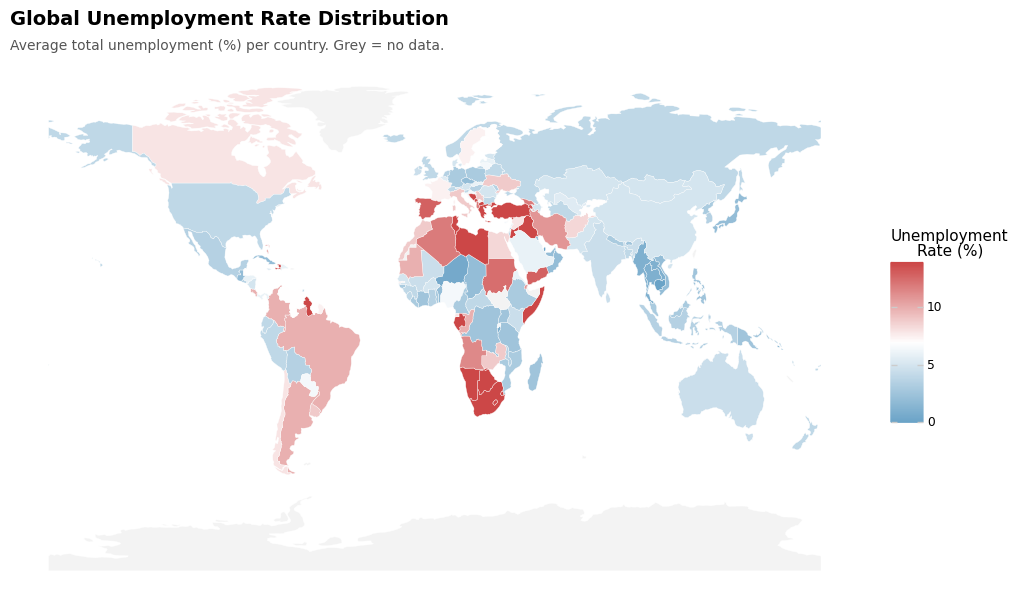

In [37]:
import geopandas as gpd
from plotnine import *
from mizani.bounds import squish
import polars as pl

# Define avg_total (missing from previous execution)
avg_total = (
    unemployment_data
    .group_by(["country", "iso3"])
    .agg(pl.col("unemployment_rate").mean().alias("avg_total_unemployment"))
    .sort("avg_total_unemployment", descending=True)
)

# 1. Load the world map geometry
world_geo = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)
world_geo = world_geo[["ADM0_A3", "geometry"]].rename(columns={"ADM0_A3": "iso3"})

# 2. Convert your Polars aggregated data to Pandas
avg_unemployment_pd = avg_total.to_pandas()

# 3. Merge the map geometry with your unemployment data
map_gdf = world_geo.merge(avg_unemployment_pd, on="iso3", how="left")

# 4. Plot the map
unemployment_map = (
    ggplot(map_gdf)
    + geom_map(aes(fill="avg_total_unemployment"), color="white", size=0.15)

    # --- DARKENED THE COLORS FOR BETTER VISIBILITY ---
    + scale_fill_gradient2(
        low="#6aa3c7",        # Darker, more solid version of your soft blue
        mid="#ffffff",        # White center
        high="#cc4747",       # Darker, more solid version of your muted red
        midpoint=7,
        limits=(0, 14),       # Keeps the colors from washing out
        oob=squish,
        na_value="#f3f3f3",
        name="Unemployment\nRate (%)"
    )
    # -------------------------------------------------

    + coord_fixed(ratio=1.3)
    + labs(title="Global Unemployment Rate Distribution",
           subtitle="Average total unemployment (%) per country. Grey = no data.",
           x="", y="")
    + theme_void()
    + theme(figure_size=(10, 6),
            plot_title=element_text(size=14, face="bold"),
            plot_subtitle=element_text(size=10, color="#555555"))
)

unemployment_map.draw()


 ## BAR CHART

The bar chart identifies the ten countries with the highest youth unemployment rates globally. By focusing on the average values, we strip away the noise of lower-unemployment nations and focus on the most extreme cases. The data shows that countries like the Palestinian Territories and South Africa lead this list, with average unemployment rates reaching between 35% and 41%. These figures represent a critical loss of human capital and highlight the severity of the employment challenge in these specific nations.

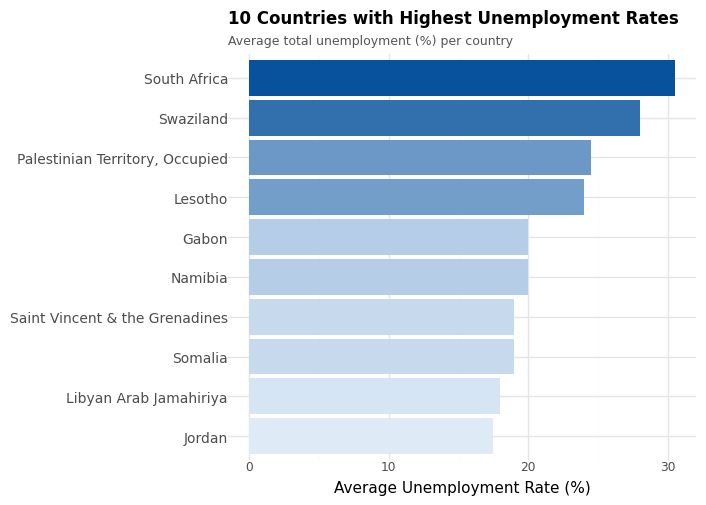

In [38]:
import pandas as pd
from plotnine import *

# 1. Grab the Top 10 countries with the HIGHEST unemployment
# (Since the data was sorted descending earlier, .head(10) gets the highest)
top10 = avg_total.head(10).to_pandas()

# 2. Sort the countries specifically for the bar chart
# We use ascending=True here. Since coord_flip() draws from the bottom up,
# this ensures the largest value (South Africa) is plotted last, placing it at the very top!
top10["country"] = pd.Categorical(
    top10["country"],
    categories=top10.sort_values("avg_total_unemployment", ascending=True)["country"],
    ordered=True
)

# 3. Create the ordered bar chart matching your exact layout
highest_unemployment_chart = (
    ggplot(top10, aes(x="country", y="avg_total_unemployment", fill="avg_total_unemployment"))
    + geom_col()
    + coord_flip()
    + scale_fill_gradient(low="#deebf7", high="#08519c")
    + labs(title="10 Countries with Highest Unemployment Rates",
           subtitle="Average total unemployment (%) per country",
           x="", y="Average Unemployment Rate (%)")
    + theme_minimal()
    + theme(figure_size=(7, 5),
            plot_title=element_text(size=12, face="bold"),
            plot_subtitle=element_text(size=9, color="#555555"),
            axis_text_y=element_text(size=10),
            legend_position="none")
)

# Force the chart to display in Colab
highest_unemployment_chart.draw()

## SCATTER PLOT

This chart highlights the persistent Gender Gap in the global workforce. By plotting the average unemployment for males, females, and the total population horizontally, we can see a clear disparity. In almost every high-unemployment country, young women face significantly higher barriers to entry than their male counterparts. In many regions, the gap between genders is wider than 10%, suggesting that economic instability disproportionately impacts young women

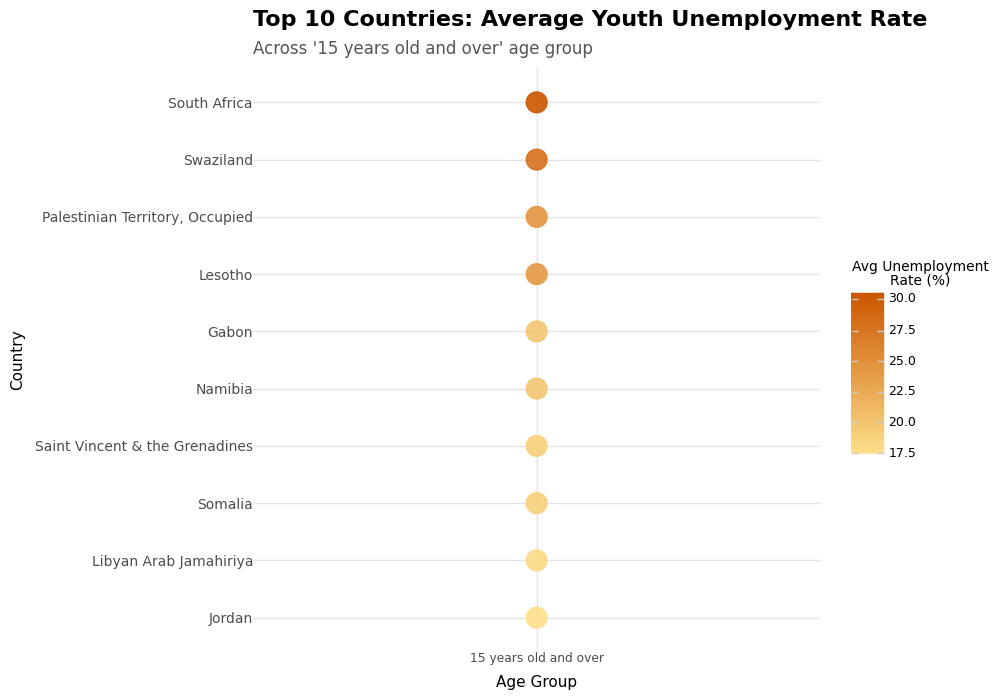

In [39]:

import polars as pl
import pandas as pd
from plotnine import *

# Prepare data for the scatter plot
# Group by country and current_age, then calculate the mean unemployment rate for 'Total' sex.
scatter_data_age_country = (
    unicef_indicator_1
    .filter(pl.col("sex") == "Total") # Focus on total unemployment
    .group_by(["country", "current_age"])
    .agg(pl.col("obs_value").mean().alias("avg_unemployment_rate"))
    .to_pandas()
)

# Assuming `top10` DataFrame is already defined and sorted from a previous cell
# 1. Get the list of top 10 country names from the already sorted `top10` DataFrame
top10_country_names = top10["country"].tolist()

# 2. Filter the scatter_data_age_country for these top 10 countries
filtered_scatter_data_age_country = scatter_data_age_country[
    scatter_data_age_country["country"].isin(top10_country_names)
].copy()

# 3. Ensure the 'country' column in the filtered data is also a categorical type with the correct order
# This uses the ordering established in the `top10` dataframe
filtered_scatter_data_age_country["country"] = pd.Categorical(
    filtered_scatter_data_age_country["country"],
    categories=top10["country"].cat.categories, # Use the existing categorical order from top10
    ordered=True
)

# 4. Create the scatter plot using the filtered and ordered data
plot_age_country = (
    ggplot(filtered_scatter_data_age_country, aes(x="current_age", y="country", color="avg_unemployment_rate"))
    + geom_point(size=8, alpha=0.9) # Slightly larger points for better visibility
    + scale_color_gradient(low="#FEE08B", high="#CC5500", name="Avg Unemployment\nRate (%)") # Orange-gold palette
    + labs(
        title="Top 10 Countries: Average Youth Unemployment Rate",
        subtitle="Across '15 years old and over' age group",
        x="Age Group",
        y="Country"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 7), # Adjusted height for 10 countries
        plot_title=element_text(size=16, face="bold"),
        plot_subtitle=element_text(size=12, color="#555555"),
        axis_text_x=element_text(angle=0, hjust=0.5), # No need to rotate if only one category
        axis_text_y=element_text(size=10),
        legend_title=element_text(size=10),
        legend_text=element_text(size=9)
    )
)

plot_age_country.draw()

In [40]:
import polars as pl

# Ensure top10_gender_data is available or recreate it if needed
# Assuming `avg_total`, `avg_female`, `avg_male` are available from previous steps

# Process the female unemployment data
female_unemployment_data = (
    unicef_indicator_1
    .filter(pl.col("sex") == "Female")
    .rename({
        "time_period": "year",
        "obs_value":   "unemployment_rate",
        "alpha_3_code": "iso3"
    })
    .select(["country", "iso3", "year", "current_age", "unemployment_rate"])
    .drop_nulls()
)

# Process the male unemployment data
male_unemployment_data = (
    unicef_indicator_1
    .filter(pl.col("sex") == "Male")
    .rename({
        "time_period": "year",
        "obs_value":   "unemployment_rate",
        "alpha_3_code": "iso3"
    })
    .select(["country", "iso3", "year", "current_age", "unemployment_rate"])
    .drop_nulls()
)

# Calculate average female unemployment
avg_female = (
    female_unemployment_data
    .group_by(["country", "iso3"])
    .agg(pl.col("unemployment_rate").mean().alias("avg_female_unemployment"))
)

# Calculate average male unemployment
avg_male = (
    male_unemployment_data
    .group_by(["country", "iso3"])
    .agg(pl.col("unemployment_rate").mean().alias("avg_male_unemployment"))
)

# Get top 10 countries based on average total unemployment
top10_countries = avg_total.sort('avg_total_unemployment', descending=True).head(10)

# Merge total, female, and male unemployment data for these top countries
top10_gender_data = (
    top10_countries
    .join(avg_female, on=['country', 'iso3'], how='left')
    .join(avg_male, on=['country', 'iso3'], how='left')
)

print("Unemployment Rate Ranges for Top 10 Countries:")
print(f"  Total Unemployment Rate: {top10_gender_data['avg_total_unemployment'].min():.2f}% - {top10_gender_data['avg_total_unemployment'].max():.2f}%")
print(f"  Female Unemployment Rate: {top10_gender_data['avg_female_unemployment'].min():.2f}% - {top10_gender_data['avg_female_unemployment'].max():.2f}%")
print(f"  Male Unemployment Rate: {top10_gender_data['avg_male_unemployment'].min():.2f}% - {top10_gender_data['avg_male_unemployment'].max():.2f}%")

Unemployment Rate Ranges for Top 10 Countries:
  Total Unemployment Rate: 17.50% - 30.50%
  Female Unemployment Rate: 17.00% - 40.50%
  Male Unemployment Rate: 14.00% - 28.50%


## LINE CHART

The line chart tracks the average unemployment rate globally from 2018 to 2024. By using the average measure, we can observe a realistic trend across the years rather than inflated totals. The data reveals that the gender gap is not a one-time event but a consistent structural issue; female unemployment rates remain significantly higher than male rates throughout the entire six-year period. This confirms that the challenges facing young job seekers are persistent and require long-term policy solutions.

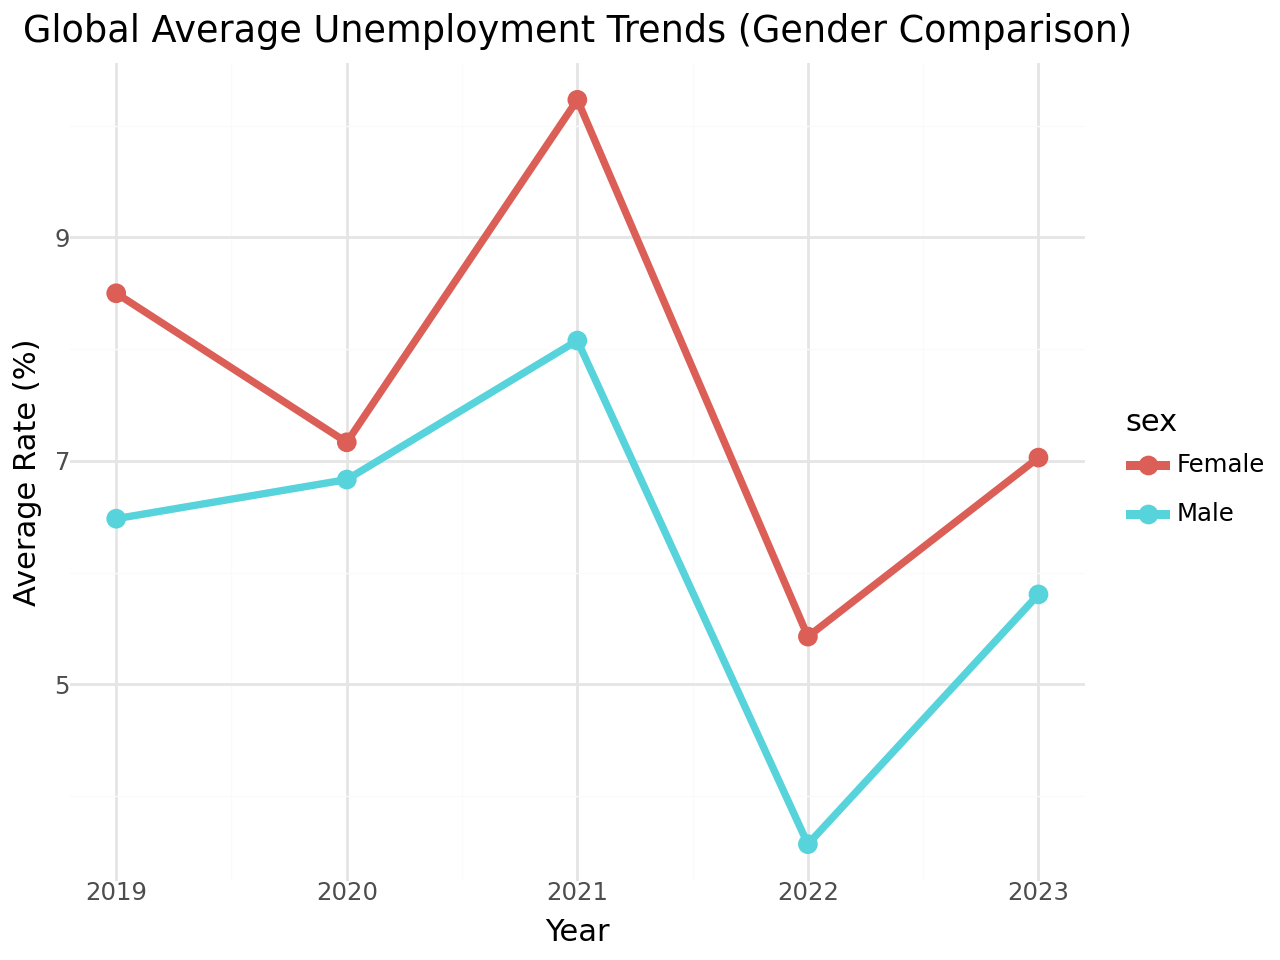

In [41]:
# Group by year and sex to get global averages
df_time_polars = unicef_indicator_1.filter(pl.col('sex').is_in(['Male', 'Female'])).group_by(['time_period', 'sex']).agg(pl.col('obs_value').mean().alias('obs_value'))
df_time = df_time_polars.to_pandas()

(ggplot(df_time, aes(x='time_period', y='obs_value', color='sex', group='sex'))
 + geom_line(size=1.5)
 + geom_point(size=3)
 + labs(title="Global Average Unemployment Trends (Gender Comparison)",
        x="Year", y="Average Rate (%)")
 + theme_minimal())